Step 1: Setting up Portfolio Parameters and Scenarios...

Step 2: Computing Analytical Conditional Default Rates...

=== Analytical Stress Testing Summary ===
                             Scenario  Systemic Factor (Z) Conditional PD Expected Defaults  Total Loss ($)
             Baseline (Normal Growth)                 0.00        3.1004%            31,004  $85,261,175.37
             Adverse (Mild Recession)                -1.28        8.1724%            81,724 $224,741,841.33
Severely Adverse (Stagflation Crisis)                -2.33       15.7249%           157,249 $432,435,117.59

Step 3: Generating Tail Risk Distribution via Vectorized Monte Carlo...

=== Simulated Portfolio Tail Risk Measures ===
  99% Value-at-Risk (VaR):    $430,129,112.46
  99% Expected Shortfall (ES): $532,605,310.89

Step 4: Compiling Loss Distribution Plots...


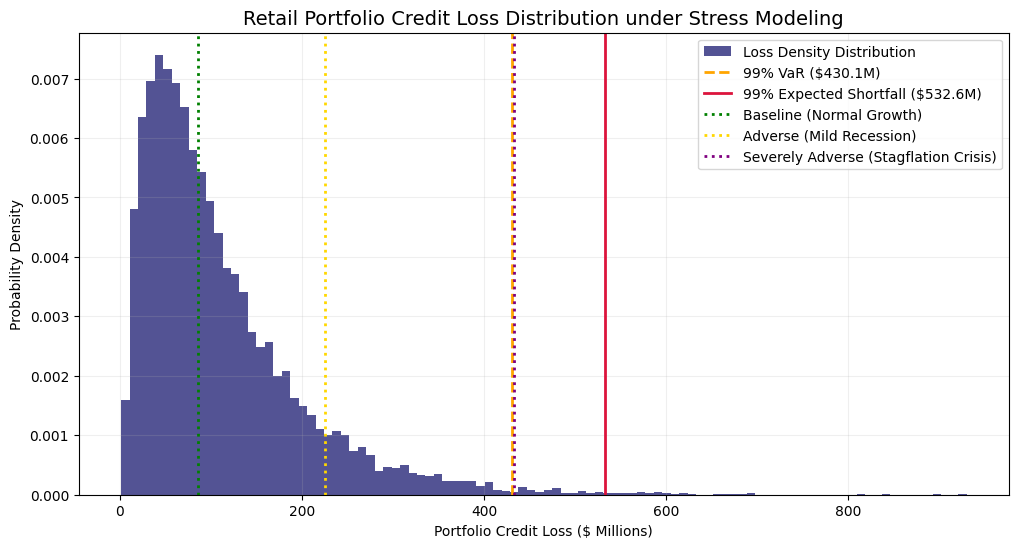


=== Pipeline Execution Complete ===


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================================
# STEP 1: DEFINE PORTFOLIO & MACRO SCENARIOS
# ==========================================================
print("Step 1: Setting up Portfolio Parameters and Scenarios...")

n_loans = 1000000          # 1 Million retail loans
portfolio_value = 5000000000 # Total portfolio value ($5 Billion)
avg_loan_size = portfolio_value / n_loans
lgd = 0.55                 # Loss Given Default (Banks lose 55% of the asset size upon default)
baseline_pd = 0.04         # Unconditional baseline default rate (4.0%)
asset_correlation = 0.12   # Rho: 12% asset correlation tracking the macroeconomy

# Define Macroeconomic Scenarios mapped to standard deviations (Z)
scenarios = {
    'Baseline (Normal Growth)': 0.0,
    'Adverse (Mild Recession)': -1.28,      # 1-in-10 year event
    'Severely Adverse (Stagflation Crisis)': -2.33 # 1-in-100 year event
}

# ==========================================================
# STEP 2: ANALYTICAL STRESS TESTING (VASICEK CONDITIONAL PD)
# ==========================================================
print("\nStep 2: Computing Analytical Conditional Default Rates...")

results_summary = []

for name, Z in scenarios.items():
    # Evaluate the structural Vasicek conditional PD equation
    numerator = norm.ppf(baseline_pd) - np.sqrt(asset_correlation) * Z
    denominator = np.sqrt(1 - asset_correlation)
    conditional_pd = norm.cdf(numerator / denominator)

    # Calculate expected credit losses
    expected_defaults = n_loans * conditional_pd
    portfolio_loss = expected_defaults * avg_loan_size * lgd

    results_summary.append({
        'Scenario': name,
        'Systemic Factor (Z)': Z,
        'Conditional PD': conditional_pd,
        'Expected Defaults': int(expected_defaults),
        'Total Loss ($)': portfolio_loss
    })

df_analytical = pd.DataFrame(results_summary)
print("\n=== Analytical Stress Testing Summary ===")
print(df_analytical.to_string(index=False, formatters={'Conditional PD': '{:.4%}'.format, 'Total Loss ($)': '${:,.2f}'.format, 'Expected Defaults': '{:,}'.format}))


# ==========================================================
# STEP 3: VECTORIZED MONTE CARLO RISK TAIL EXPANSION
# ==========================================================
print("\nStep 3: Generating Tail Risk Distribution via Vectorized Monte Carlo...")

np.random.seed(42)
n_simulations = 10000

# Simulate 10,000 distinct parallel universes for the macro factor Z
Z_sim = np.random.normal(0, 1, n_simulations)

# Calculate conditional PD for every simulated universe
num_sim = norm.ppf(baseline_pd) - np.sqrt(asset_correlation) * Z_sim
den_sim = np.sqrt(1 - asset_correlation)
pd_sim = norm.cdf(num_sim / den_sim)

# Compute portfolio dollar losses for all universes simultaneously
portfolio_losses_sim = pd_sim * n_loans * avg_loan_size * lgd

# Extract Tail Risk Measures (Value-at-Risk and Expected Shortfall)
var_99 = np.percentile(portfolio_losses_sim, 99)
es_99 = portfolio_losses_sim[portfolio_losses_sim >= var_99].mean()

print("\n=== Simulated Portfolio Tail Risk Measures ===")
print(f"  99% Value-at-Risk (VaR):    ${var_99:,.2f}")
print(f"  99% Expected Shortfall (ES): ${es_99:,.2f}")


# ==========================================================
# STEP 4: VISUALIZE CREDIT LOSS DENSITY TAIL
# ==========================================================
print("\nStep 4: Compiling Loss Distribution Plots...")

plt.figure(figsize=(12, 6))
plt.hist(portfolio_losses_sim / 1e6, bins=100, density=True, color='midnightblue', alpha=0.75, label='Loss Density Distribution')
plt.axvline(var_99 / 1e6, color='orange', linestyle='--', linewidth=2, label=f'99% VaR (${var_99/1e6:.1f}M)')
plt.axvline(es_99 / 1e6, color='crimson', linestyle='-', linewidth=2, label=f'99% Expected Shortfall (${es_99/1e6:.1f}M)')

# Highlight scenario loss hits
colors = ['green', 'gold', 'purple']
for idx, row in df_analytical.iterrows():
    plt.axvline(row['Total Loss ($)'] / 1e6, color=colors[idx], linestyle=':', linewidth=2, label=f"{row['Scenario']}")

plt.title('Retail Portfolio Credit Loss Distribution under Stress Modeling', fontsize=14)
plt.xlabel('Portfolio Credit Loss ($ Millions)')
plt.ylabel('Probability Density')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

print("\n=== Pipeline Execution Complete ===")